# **PRODIGY_DS_04**

# **Sentiment Analysis and Visualization of Social Media Data**

Internship: Prodigy Infotech

Domain: Data Science

Task: 04

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["ID", "Topic", "Sentiment", "Tweet"]
)

df.head()

,ID,Topic,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Topic      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [4]:
df.describe()

,ID
count,74682.000000
mean,6432.586165
std,3740.427870
min,1.000000
25%,3195.000000
50%,6422.000000
75%,9601.000000
max,13200.000000


In [5]:
df.isnull().sum()

,0
ID,0
Topic,0
Sentiment,0
Tweet,686


In [6]:
# Remove rows with missing tweets
df = df.dropna(subset=['Tweet'])

# Check missing values again
df.isnull().sum()

,0
ID,0
Topic,0
Sentiment,0
Tweet,0


In [7]:
df['Sentiment'].value_counts()

,count
Sentiment,
Negative,22358
Positive,20655
Neutral,18108
Irrelevant,12875


In [8]:
df['Topic'].nunique()

32

In [9]:
df['Topic'].unique()

array(['Borderlands', 'CallOfDutyBlackopsColdWar', 'Amazon', 'Overwatch',
       'Xbox(Xseries)', 'NBA2K', 'Dota2', 'PlayStation5(PS5)',
       'WorldOfCraft', 'CS-GO', 'Google', 'AssassinsCreed', 'ApexLegends',
       'LeagueOfLegends', 'Fortnite', 'Microsoft', 'Hearthstone',
       'Battlefield', 'PlayerUnknownsBattlegrounds(PUBG)', 'Verizon',
       'HomeDepot', 'FIFA', 'RedDeadRedemption(RDR)', 'CallOfDuty',
       'TomClancysRainbowSix', 'Facebook', 'GrandTheftAuto(GTA)',
       'MaddenNFL', 'johnson&johnson', 'Cyberpunk2077',
       'TomClancysGhostRecon', 'Nvidia'], dtype=object)

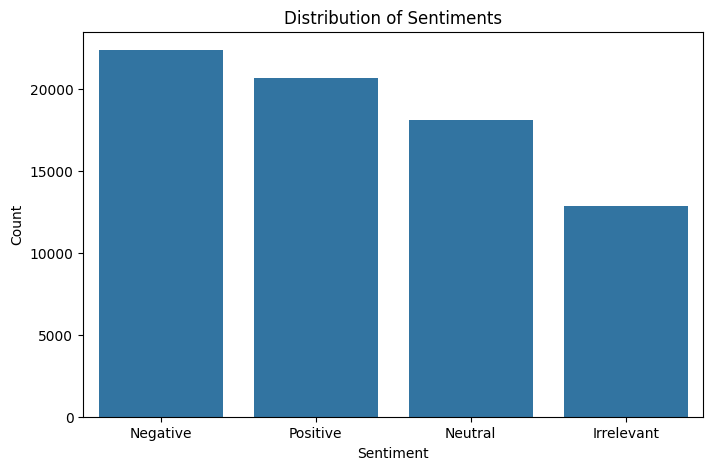

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Sentiment', order=df['Sentiment'].value_counts().index)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

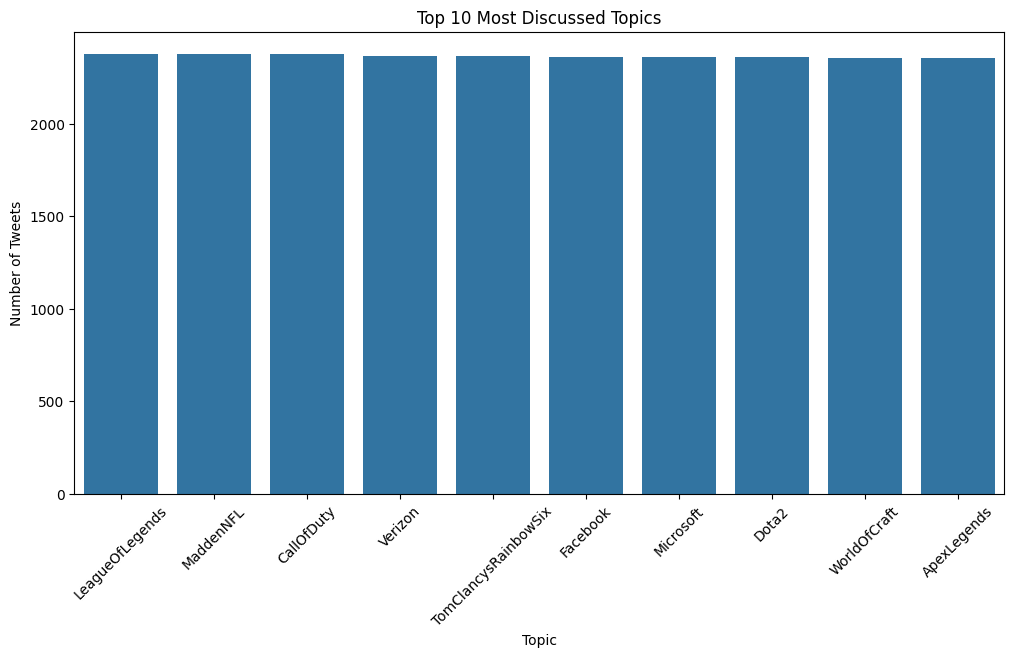

In [11]:
plt.figure(figsize=(12,6))

top_topics = df['Topic'].value_counts().head(10)

sns.barplot(x=top_topics.index, y=top_topics.values)

plt.title("Top 10 Most Discussed Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)

plt.show()

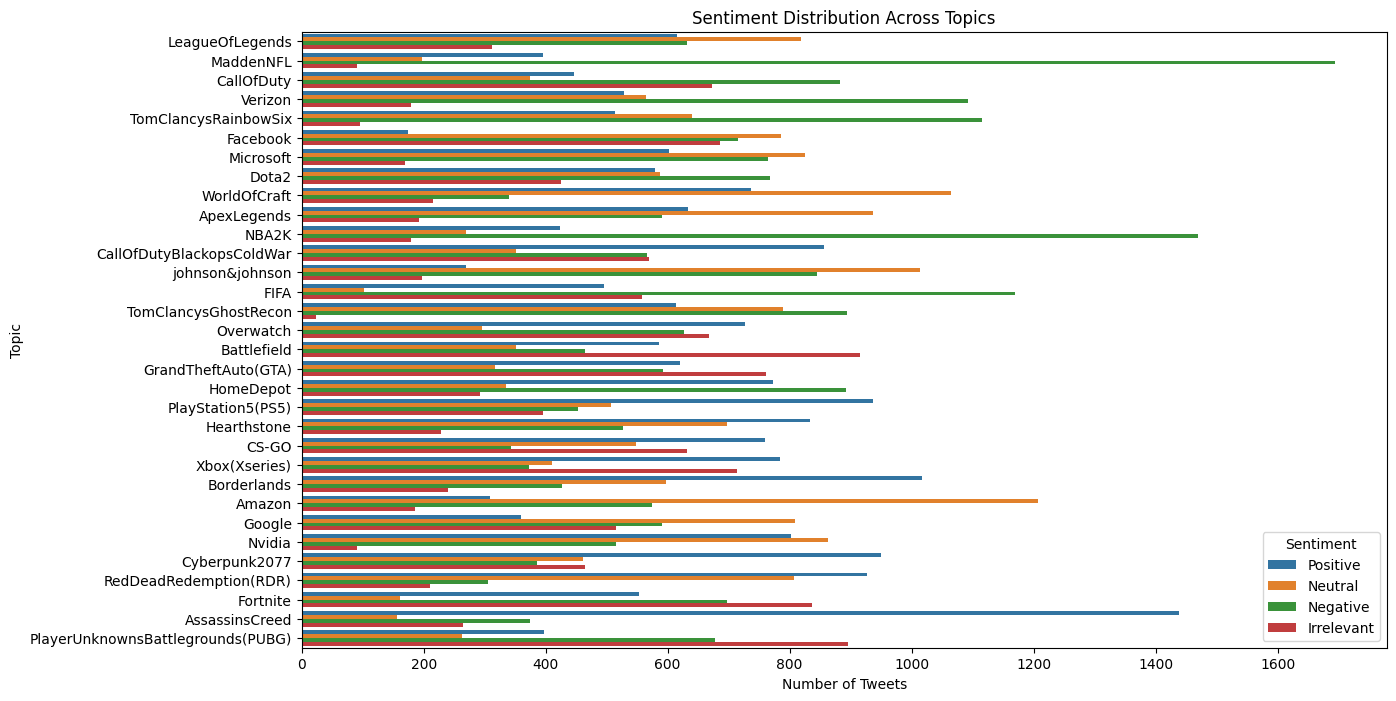

In [12]:
plt.figure(figsize=(14,8))

sns.countplot(
    data=df,
    y='Topic',
    hue='Sentiment',
    order=df['Topic'].value_counts().index
)

plt.title("Sentiment Distribution Across Topics")
plt.xlabel("Number of Tweets")
plt.ylabel("Topic")

plt.show()

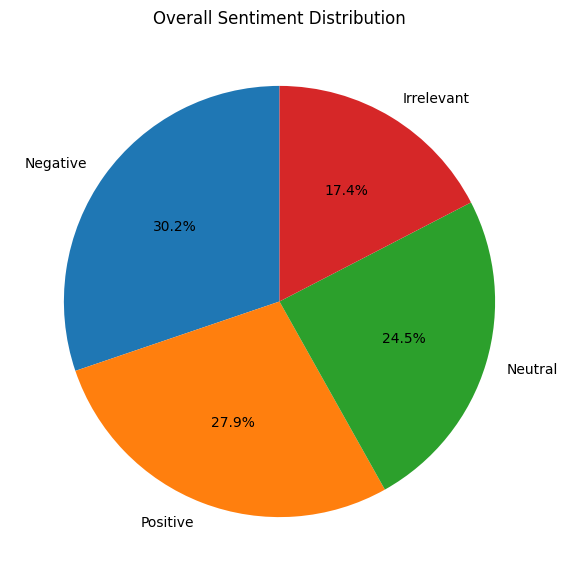

In [13]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Overall Sentiment Distribution")

plt.show()